In [ ]:
# Análisis completo de MNIST (mnist_test 1.csv): Clasificación de dígitos escritos a mano
# Script unificado para Google Colab

# Importar todas las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import validation_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

# prompt: cargar dataset fasionmnist

import tensorflow as tf

# Load the Fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


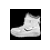

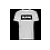

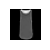

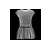

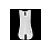

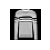

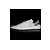

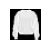

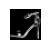

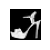

In [ ]:
# prompt: graficar las primeras 10 imagenes escalando a 0.5 0.5

import matplotlib.pyplot as plt

# Assuming 'train_images' from the provided code contains the Fashion MNIST images
# and it's already loaded as in the original code.

# Display the first 10 images, scaled to 0.5 x 0.5
for i in range(10):
    plt.figure(figsize=(0.4, 0.4))  # Adjust figure size for smaller images
    plt.imshow(train_images[i], cmap='gray')
    plt.axis('off')
    plt.show()


In [ ]:
# Definir nombres de clases para mejor interpretación
class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

print(f"Datos cargados: {train_images.shape[0]} imágenes de entrenamiento, {test_images.shape[0]} imágenes de prueba")
print(f"Tamaño de las imágenes: {train_images.shape[1]}x{train_images.shape[2]} píxeles")

# Mostrar algunos datos
print("\nPrimeras etiquetas de entrenamiento:")
print(train_labels[:10])
print("\nClases correspondientes:")
for i in range(10):
    print(f"{train_labels[i]}: {class_names[train_labels[i]]}")

# Normalizar los valores de píxeles (de 0-255 a 0-1)
X_train = train_images / 255.0
X_test = test_images / 255.0
y_train = train_labels
y_test = test_labels

print("\nRango de valores de píxeles antes de normalizar:", train_images.min(), "a", train_images.max())
print("Rango de valores de píxeles después de normalizar:", X_train.min(), "a", X_train.max())

# Verificar la distribución de clases
train_distribution = pd.Series(y_train).value_counts().sort_index()
test_distribution = pd.Series(y_test).value_counts().sort_index()

print("\nDistribución de clases en entrenamiento:")
for i, count in enumerate(train_distribution):
    print(f"{i}: {class_names[i]} - {count} ejemplos")

print("\nDistribución de clases en prueba:")
for i, count in enumerate(test_distribution):
    print(f"{i}: {class_names[i]} - {count} ejemplos")


Datos cargados: 60000 imágenes de entrenamiento, 10000 imágenes de prueba
Tamaño de las imágenes: 28x28 píxeles

Primeras etiquetas de entrenamiento:
[9 0 0 3 0 2 7 2 5 5]

Clases correspondientes:
9: Botín
0: Camiseta/Top
0: Camiseta/Top
3: Vestido
0: Camiseta/Top
2: Suéter
7: Zapatilla
2: Suéter
5: Sandalia
5: Sandalia

Rango de valores de píxeles antes de normalizar: 0 a 255
Rango de valores de píxeles después de normalizar: 0.0 a 1.0

Distribución de clases en entrenamiento:
0: Camiseta/Top - 6000 ejemplos
1: Pantalón - 6000 ejemplos
2: Suéter - 6000 ejemplos
3: Vestido - 6000 ejemplos
4: Abrigo - 6000 ejemplos
5: Sandalia - 6000 ejemplos
6: Camisa - 6000 ejemplos
7: Zapatilla - 6000 ejemplos
8: Bolso - 6000 ejemplos
9: Botín - 6000 ejemplos

Distribución de clases en prueba:
0: Camiseta/Top - 1000 ejemplos
1: Pantalón - 1000 ejemplos
2: Suéter - 1000 ejemplos
3: Vestido - 1000 ejemplos
4: Abrigo - 1000 ejemplos
5: Sandalia - 1000 ejemplos
6: Camisa - 1000 ejemplos
7: Zapatilla - 1


PARTE 2: EXPLORACIÓN Y VISUALIZACIÓN


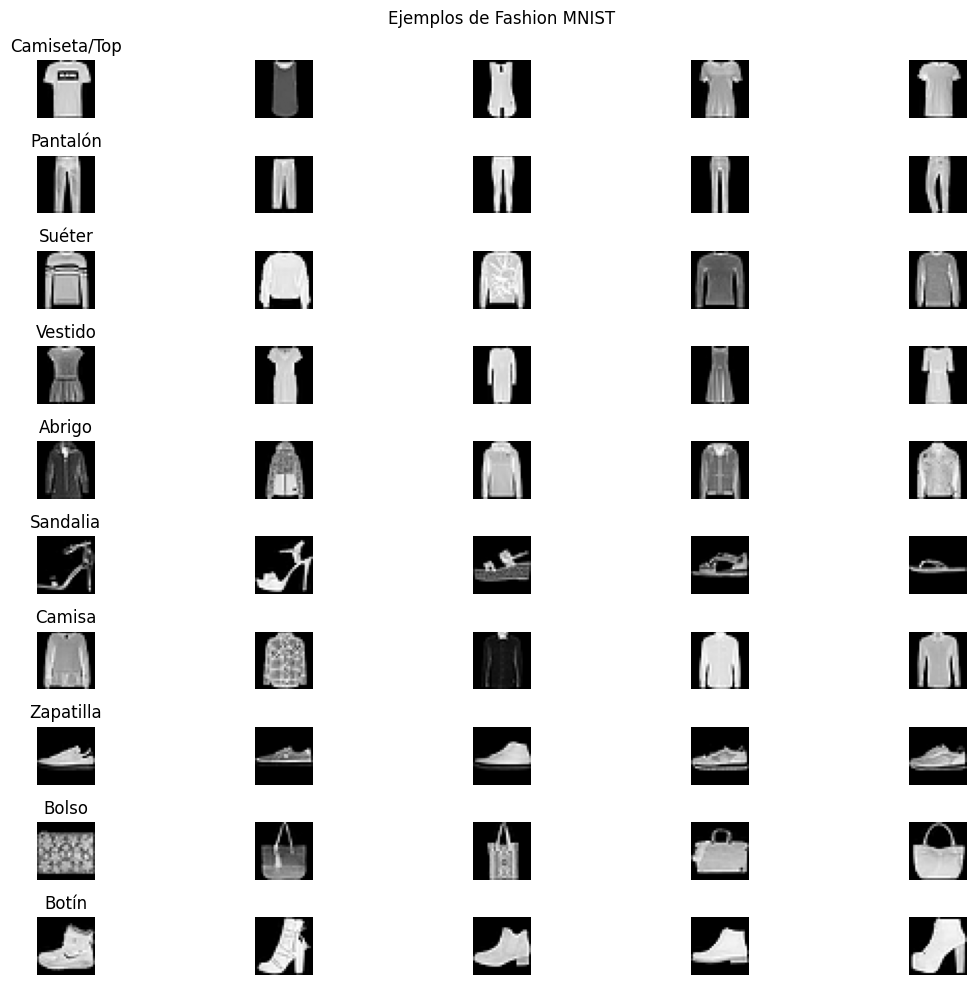

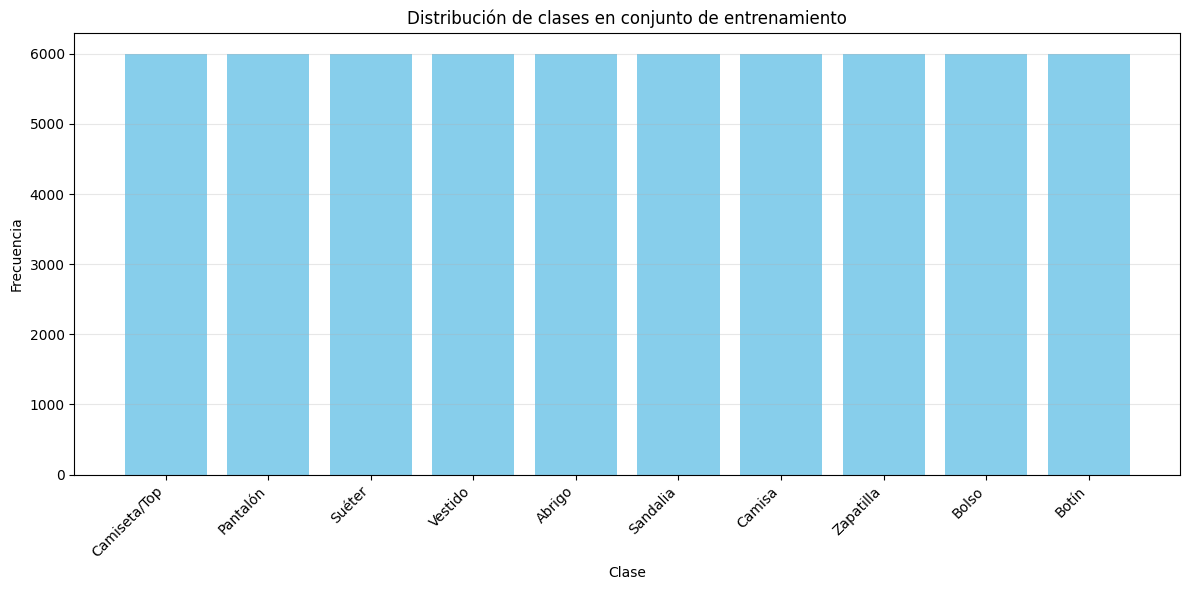


Analizando el ejemplo #41839:
Etiqueta: 3 (Vestido)


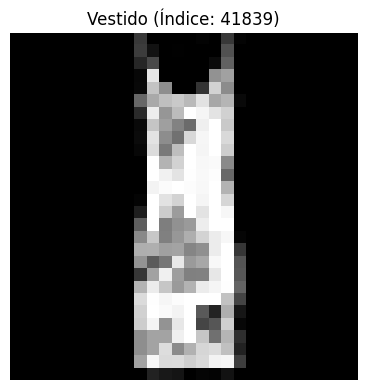


Intensidad de píxeles (valores entre 0 y 1):


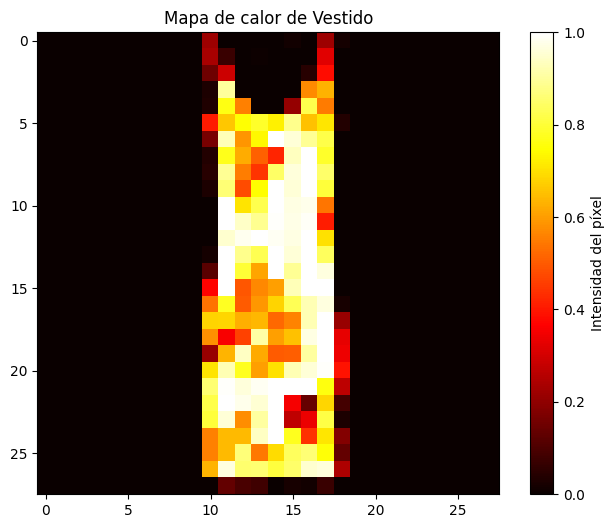

In [ ]:
# PARTE 2: EXPLORACIÓN Y VISUALIZACIÓN
print("\n" + "="*50)
print("PARTE 2: EXPLORACIÓN Y VISUALIZACIÓN")
print("="*50)

# Función para visualizar una prenda
def visualize_item(data, label=None, index=None):
    plt.figure(figsize=(4, 4))
    plt.imshow(data, cmap='gray')

    title = f"{class_names[label]}" if label is not None else ""
    if index is not None:
        title += f" (Índice: {index})"
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualizar algunos ejemplos de cada clase
plt.figure(figsize=(12, 10))
num_examples = 5
for label in range(10):
    # Encontrar índices de esta clase
    indices = np.where(y_train == label)[0]

    # Tomar los primeros 'num_examples' ejemplos
    for i, idx in enumerate(indices[:num_examples]):
        plt.subplot(10, num_examples, label*num_examples + i + 1)
        plt.imshow(X_train[idx], cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title(f'{class_names[label]}')

plt.suptitle('Ejemplos de Fashion MNIST')
plt.tight_layout()
plt.show()

# Visualizar la distribución de clases
plt.figure(figsize=(12, 6))
plt.bar(range(10), train_distribution, color='skyblue')
plt.xticks(range(10), [class_names[i] for i in range(10)], rotation=45, ha='right')
plt.title('Distribución de clases en conjunto de entrenamiento')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Examinar un ejemplo con mayor detalle
# Elegir un ejemplo aleatorio
random_index = np.random.randint(0, len(X_train))
print(f"\nAnalizando el ejemplo #{random_index}:")
print(f"Etiqueta: {y_train[random_index]} ({class_names[y_train[random_index]]})")

# Visualizar el ejemplo
visualize_item(X_train[random_index], y_train[random_index], random_index)

# Mostrar los valores de píxeles del ejemplo
print("\nIntensidad de píxeles (valores entre 0 y 1):")
plt.figure(figsize=(8, 6))
plt.imshow(X_train[random_index], cmap='hot')
plt.colorbar(label='Intensidad del píxel')
plt.title(f'Mapa de calor de {class_names[y_train[random_index]]}')
plt.show()


PARTE 3: ENTRENAMIENTO Y EVALUACIÓN DEL MODELO k-NN
Dimensiones de X_train aplanado: (60000, 784)
Dimensiones de X_test aplanado: (10000, 784)
Entrenando modelo k-NN...
Tiempo de entrenamiento: 0.18 segundos

Evaluando el modelo en datos de prueba...
Tiempo de evaluación: 44.31 segundos

Precisión del modelo: 0.8554 (o 85.54%)

Matriz de confusión:
[[855   1  17  16   3   1 100   1   6   0]
 [  8 968   4  12   4   0   3   0   1   0]
 [ 24   2 819  11  75   0  69   0   0   0]
 [ 41   8  15 860  39   0  34   0   3   0]
 [  2   1 126  26 773   0  71   0   1   0]
 [  1   0   0   0   0 822   5  96   1  75]
 [176   1 132  23  80   0 575   0  13   0]
 [  0   0   0   0   0   3   0 961   0  36]
 [  2   0  10   4   7   0  16   7 953   1]
 [  0   0   0   0   0   2   1  29   0 968]]

Reporte de clasificación:
              precision    recall  f1-score   support

Camiseta/Top       0.77      0.85      0.81      1000
    Pantalón       0.99      0.97      0.98      1000
      Suéter       0.73    

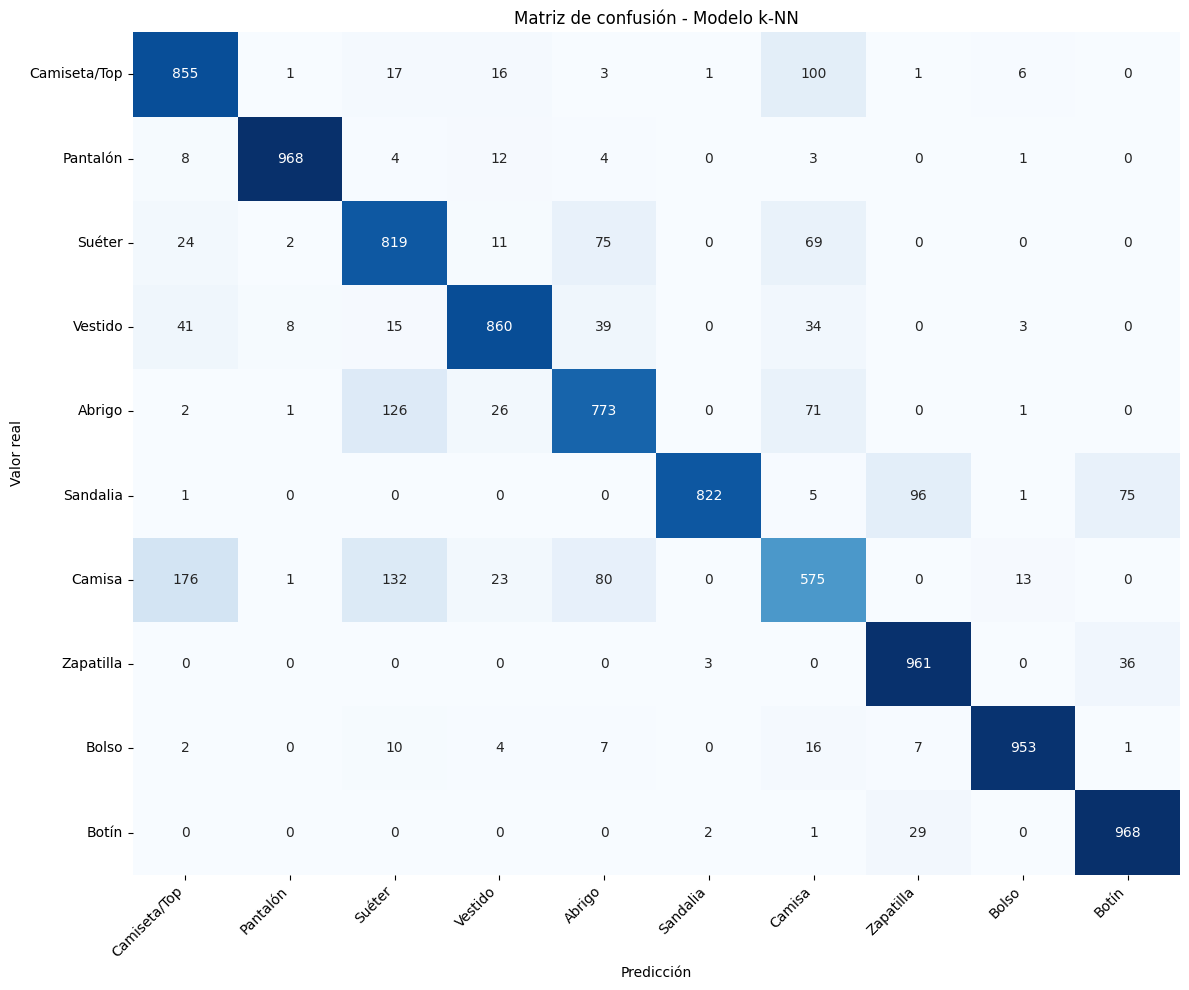


Total de clasificaciones incorrectas: 1446


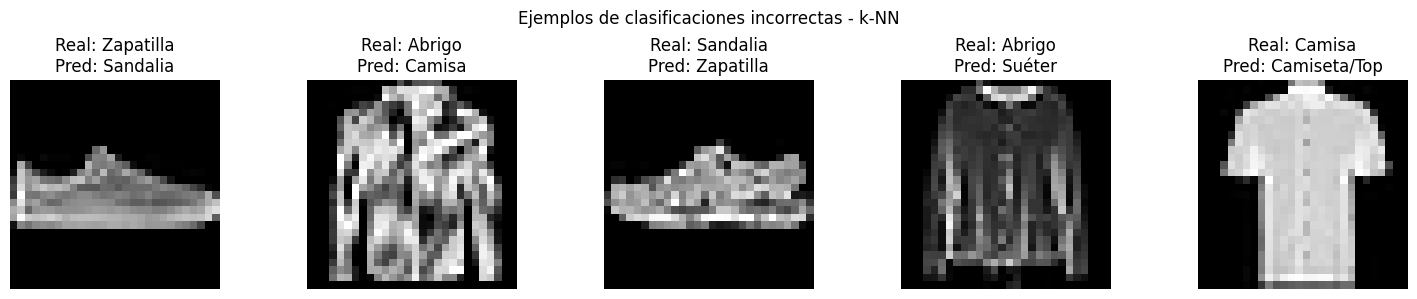

In [ ]:
# PARTE 3: MODELO k-NN
print("\n" + "="*50)
print("PARTE 3: ENTRENAMIENTO Y EVALUACIÓN DEL MODELO k-NN")
print("="*50)

# Aplanar las imágenes para los modelos tradicionales
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Dimensiones de X_train aplanado: {X_train_flat.shape}")
print(f"Dimensiones de X_test aplanado: {X_test_flat.shape}")

# Crear y entrenar el modelo k-NN
print("Entrenando modelo k-NN...")
start_time = time.time()

# Crear el clasificador con k=5 (5 vecinos más cercanos)
knn = KNeighborsClassifier(n_neighbors=5)

# Entrenar el modelo
knn.fit(X_train_flat, y_train)

training_time = time.time() - start_time
print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")

# Evaluar el modelo
print("\nEvaluando el modelo en datos de prueba...")
start_time = time.time()

# Predecir en el conjunto de prueba
y_pred_knn = knn.predict(X_test_flat)

evaluation_time = time.time() - start_time
print(f"Tiempo de evaluación: {evaluation_time:.2f} segundos")

# Calcular la precisión
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nPrecisión del modelo: {accuracy_knn:.4f} (o {accuracy_knn*100:.2f}%)")

# Matriz de confusión
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("\nMatriz de confusión:")
print(cm_knn)

# Reporte de clasificación
report_knn = classification_report(y_test, y_pred_knn, target_names=class_names)
print("\nReporte de clasificación:")
print(report_knn)

# Visualizar la matriz de confusión
plt.figure(figsize=(12, 10))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de confusión - Modelo k-NN')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Analizar algunas clasificaciones incorrectas
# Encontrar índices de clasificaciones incorrectas
incorrect_indices_knn = np.where(y_pred_knn != y_test)[0]
print(f"\nTotal de clasificaciones incorrectas: {len(incorrect_indices_knn)}")

# Mostrar algunos ejemplos mal clasificados
num_examples = min(5, len(incorrect_indices_knn))
plt.figure(figsize=(15, 3))
for i in range(num_examples):
    idx = incorrect_indices_knn[i]

    plt.subplot(1, num_examples, i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f'Real: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_knn[idx]]}')
    plt.axis('off')

plt.suptitle('Ejemplos de clasificaciones incorrectas - k-NN')
plt.tight_layout()
plt.show()



PARTE 4: ENTRENAMIENTO Y EVALUACIÓN DEL MODELO RANDOM FOREST
Entrenando modelo Random Forest...
Tiempo de entrenamiento: 96.48 segundos

Evaluando el modelo en datos de prueba...
Tiempo de evaluación: 0.39 segundos

Precisión del modelo Random Forest: 0.8764 (o 87.64%)

Matriz de confusión:
[[861   0  14  27   4   1  80   0  13   0]
 [  1 963   2  21   4   0   8   0   1   0]
 [  9   0 810   9 108   0  58   0   6   0]
 [ 19   4  10 901  36   0  28   0   2   0]
 [  0   0  91  35 820   0  52   0   2   0]
 [  0   0   0   1   0 959   0  28   1  11]
 [159   1 124  28  90   1 581   0  16   0]
 [  0   0   0   0   0  10   0 953   0  37]
 [  1   1   5   3   4   1   7   4 973   1]
 [  0   0   0   0   0   9   1  45   2 943]]

Reporte de clasificación:
              precision    recall  f1-score   support

Camiseta/Top       0.82      0.86      0.84      1000
    Pantalón       0.99      0.96      0.98      1000
      Suéter       0.77      0.81      0.79      1000
     Vestido       0.88      0.9

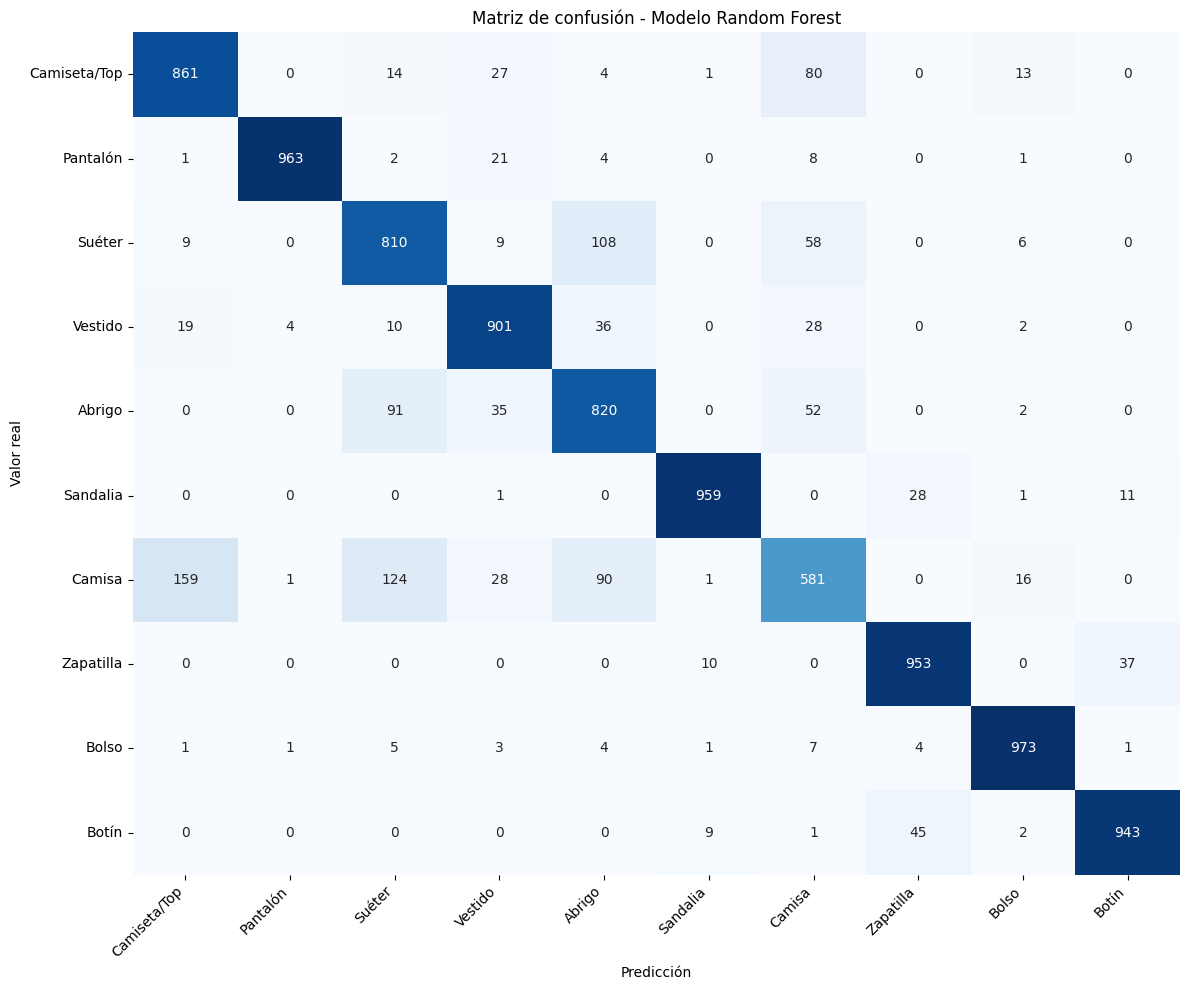

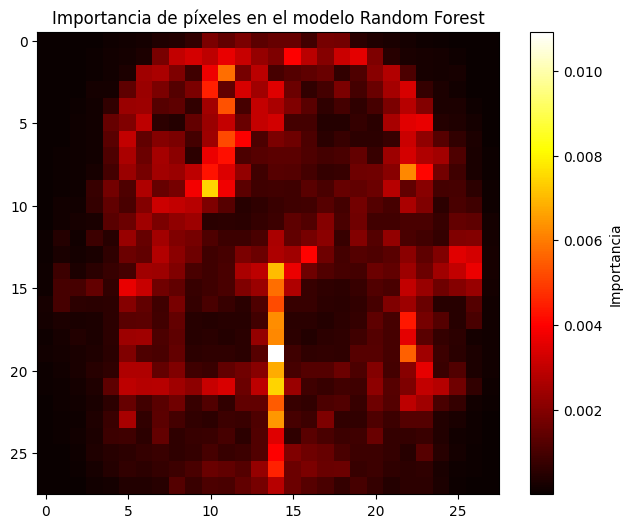

In [ ]:
# PARTE 4: MODELO RANDOM FOREST
print("\n" + "="*50)
print("PARTE 4: ENTRENAMIENTO Y EVALUACIÓN DEL MODELO RANDOM FOREST")
print("="*50)

# Crear y entrenar el modelo Random Forest
print("Entrenando modelo Random Forest...")
start_time = time.time()

# Crear el clasificador con menos árboles para que sea más rápido
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Entrenar el modelo
rf.fit(X_train_flat, y_train)

training_time = time.time() - start_time
print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")

# Evaluar el modelo
print("\nEvaluando el modelo en datos de prueba...")
start_time = time.time()

# Predecir en el conjunto de prueba
y_pred_rf = rf.predict(X_test_flat)

evaluation_time = time.time() - start_time
print(f"Tiempo de evaluación: {evaluation_time:.2f} segundos")

# Calcular la precisión
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nPrecisión del modelo Random Forest: {accuracy_rf:.4f} (o {accuracy_rf*100:.2f}%)")

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nMatriz de confusión:")
print(cm_rf)

# Reporte de clasificación
report_rf = classification_report(y_test, y_pred_rf, target_names=class_names)
print("\nReporte de clasificación:")
print(report_rf)

# Visualizar la matriz de confusión
plt.figure(figsize=(12, 10))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de confusión - Modelo Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Analizar la importancia de características
# Obtener la importancia de características
feature_importance = rf.feature_importances_

# Reorganizar la importancia en forma de imagen (28x28)
importance_image = feature_importance.reshape(28, 28)

# Visualizar la importancia de los píxeles
plt.figure(figsize=(8, 6))
plt.imshow(importance_image, cmap='hot')
plt.colorbar(label='Importancia')
plt.title('Importancia de píxeles en el modelo Random Forest')
plt.show()


PARTE 5: ENTRENAMIENTO Y EVALUACIÓN DEL MODELO DE REGRESIÓN LOGÍSTICA
Entrenando modelo de Regresión Logística...
Tiempo de entrenamiento: 241.53 segundos

Evaluando el modelo en datos de prueba...
Tiempo de evaluación: 0.03 segundos

Precisión del modelo de Regresión Logística: 0.8441 (o 84.41%)

Matriz de confusión:
[[805   2  11  53   5   3 111   0  10   0]
 [  5 956   4  26   4   0   3   0   2   0]
 [ 23   4 740  10 126   1  83   1  12   0]
 [ 26  14  17 864  29   0  39   0  11   0]
 [  0   2 115  36 761   0  79   0   7   0]
 [  1   0   0   1   0 924   0  49   4  21]
 [141   2 124  38 104   0 569   0  22   0]
 [  0   0   0   0   0  30   0 941   0  29]
 [  7   1   9  13   3   5  21   5 936   0]
 [  0   1   0   0   0  13   1  40   0 945]]

Reporte de clasificación:
              precision    recall  f1-score   support

Camiseta/Top       0.80      0.81      0.80      1000
    Pantalón       0.97      0.96      0.96      1000
      Suéter       0.73      0.74      0.73      1000
    

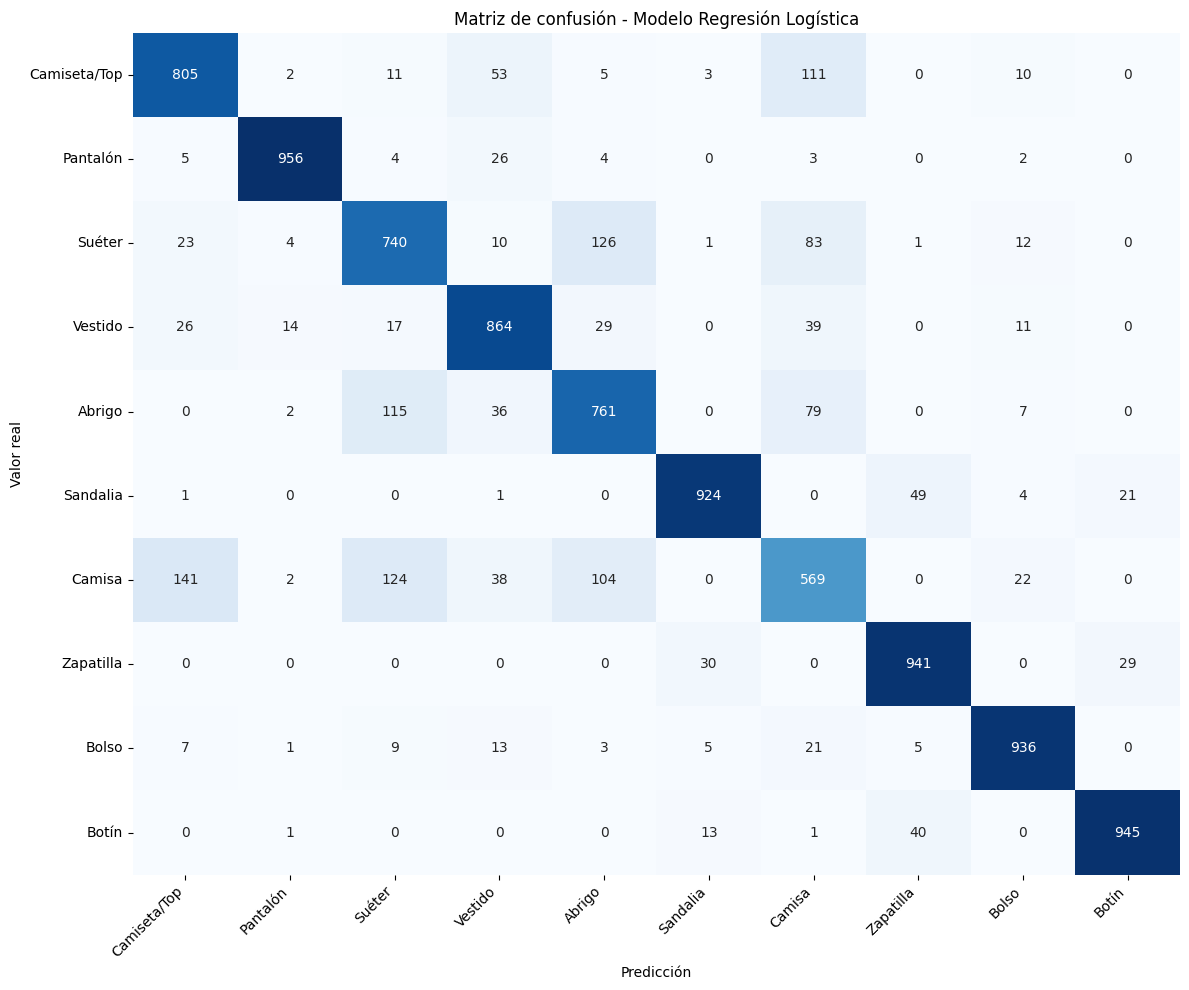

In [ ]:
# PARTE 5: MODELO DE REGRESIÓN LOGÍSTICA
print("\n" + "="*50)
print("PARTE 5: ENTRENAMIENTO Y EVALUACIÓN DEL MODELO DE REGRESIÓN LOGÍSTICA")
print("="*50)

# Crear y entrenar el modelo de Regresión Logística
print("Entrenando modelo de Regresión Logística...")
start_time = time.time()

# Crear el clasificador
lr = LogisticRegression(max_iter=100, solver='saga', n_jobs=-1, random_state=42)

# Entrenar el modelo
lr.fit(X_train_flat, y_train)

training_time = time.time() - start_time
print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")

# Evaluar el modelo
print("\nEvaluando el modelo en datos de prueba...")
start_time = time.time()

# Predecir en el conjunto de prueba
y_pred_lr = lr.predict(X_test_flat)

evaluation_time = time.time() - start_time
print(f"Tiempo de evaluación: {evaluation_time:.2f} segundos")

# Calcular la precisión
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\nPrecisión del modelo de Regresión Logística: {accuracy_lr:.4f} (o {accuracy_lr*100:.2f}%)")

# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nMatriz de confusión:")
print(cm_lr)

# Reporte de clasificación
report_lr = classification_report(y_test, y_pred_lr, target_names=class_names)
print("\nReporte de clasificación:")
print(report_lr)

# Visualizar la matriz de confusión
plt.figure(figsize=(12, 10))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de confusión - Modelo Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


--- Comparación de modelos tradicionales ---
Precisión k-NN: 85.54%
Precisión Random Forest: 87.64%
Precisión Regresión Logística: 84.41%


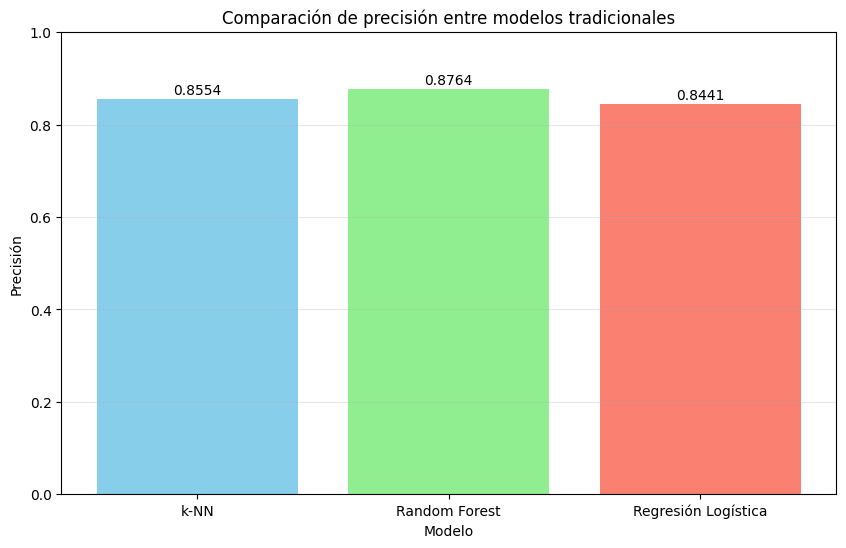


Calculando curva de validación para k-NN...


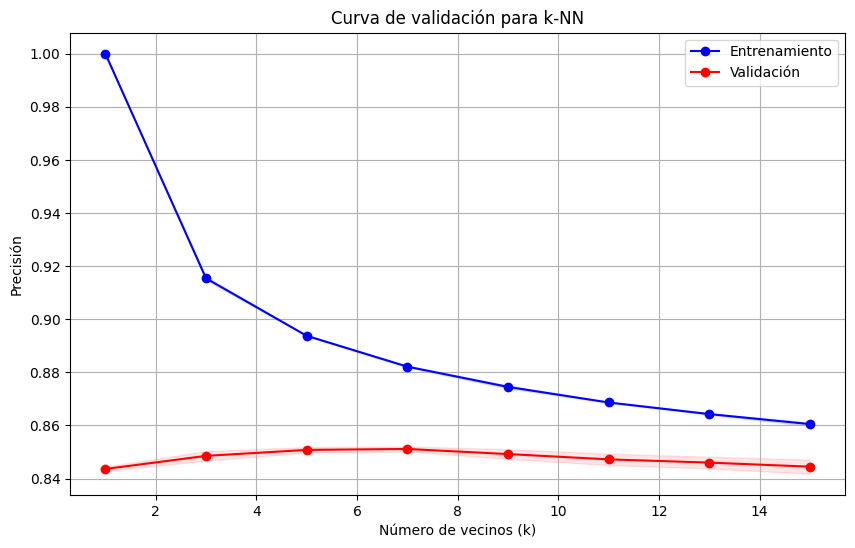

In [ ]:
# Comparación de los tres modelos tradicionales
print("\n--- Comparación de modelos tradicionales ---")
print(f"Precisión k-NN: {accuracy_knn*100:.2f}%")
print(f"Precisión Random Forest: {accuracy_rf*100:.2f}%")
print(f"Precisión Regresión Logística: {accuracy_lr*100:.2f}%")

# Gráfico comparativo
plt.figure(figsize=(10, 6))
models = ['k-NN', 'Random Forest', 'Regresión Logística']
accuracies = [accuracy_knn, accuracy_rf, accuracy_lr]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.bar(models, accuracies, color=colors)
plt.title('Comparación de precisión entre modelos tradicionales')
plt.xlabel('Modelo')
plt.ylabel('Precisión')
plt.ylim(0, 1)

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f'{acc:.4f}', ha='center')

plt.grid(axis='y', alpha=0.3)
plt.show()

# Curva de aprendizaje para k-NN con diferentes valores de k
print("\nCalculando curva de validación para k-NN...")
# Definir los valores de k para probar
k_values = [1, 3, 5, 7, 9, 11, 13, 15]

# Calcular los puntajes para cada valor de k (usar menos folds para que sea más rápido)
train_scores, test_scores = validation_curve(
    KNeighborsClassifier(), X_train_flat, y_train,
    param_name="n_neighbors", param_range=k_values,
    cv=3, scoring="accuracy", n_jobs=-1
)

# Calcular media y desviación estándar para los puntajes
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_mean, 'o-', color='blue', label='Entrenamiento')
plt.plot(k_values, test_mean, 'o-', color='red', label='Validación')
plt.fill_between(k_values, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(k_values, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
plt.title('Curva de validación para k-NN')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Precisión')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
# PARTE 6: MODELOS DE REDES NEURONALES
print("\n" + "="*50)
print("PARTE 6: ENTRENAMIENTO Y EVALUACIÓN DE REDES NEURONALES")
print("="*50)

# Verificar TensorFlow
print(f"TensorFlow versión: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Preparar los datos para las redes neuronales
# Convertir etiquetas a formato one-hot encoding
y_train_one_hot = to_categorical(y_train, 10)
y_test_one_hot = to_categorical(y_test, 10)

# 1. Red Neural Densa
print("\n--- Creando Red Neural Densa ---")
model_dense = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

# Compilar el modelo
model_dense.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen del modelo
model_dense.summary()

# 2. Red Neural Convolucional (CNN)
# Remodelar los datos para CNN (ya están en el formato correcto, solo añadimos canal)
X_train_reshaped = X_train.reshape(-1, 28, 28, 1)
X_test_reshaped = X_test.reshape(-1, 28, 28, 1)

print("\n--- Creando Red Neural Convolucional (CNN) ---")
model_cnn = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# Compilar el modelo
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen del modelo
model_cnn.summary()

# Entrenar ambos modelos (menos épocas para que sea más rápido)
print("\n--- Entrenando modelo denso ---")
history_dense = model_dense.fit(
    X_train_flat, y_train_one_hot,
    epochs=5,  # Reducido para Colab
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("\n--- Entrenando modelo CNN ---")
history_cnn = model_cnn.fit(
    X_train_reshaped, y_train_one_hot,
    epochs=5,  # Reducido para Colab
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


PARTE 6: ENTRENAMIENTO Y EVALUACIÓN DE REDES NEURONALES
TensorFlow versión: 2.18.0
GPU disponible: False

--- Creando Red Neural Densa ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


--- Entrenando modelo denso ---
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6615 - loss: 0.9666 - val_accuracy: 0.8443 - val_loss: 0.4303
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8359 - loss: 0.4701 - val_accuracy: 0.8563 - val_loss: 0.3881
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8511 - loss: 0.4123 - val_accuracy: 0.8575 - val_loss: 0.3724
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8632 - loss: 0.3791 - val_accuracy: 0.8682 - val_loss: 0.3512
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8688 - loss: 0.3626 - val_accuracy: 0.8697 - val_loss: 0.3400

--- Entrenando modelo CNN ---
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 104ms/step - accuracy: 0.6883 - loss: 0.8846 - val_accuracy: 0.8532 - val_loss: 0.3933
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - accuracy: 0.8546 - loss: 0.4019 - val_accuracy: 0.8773 - val_loss: 0.3369
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 82


PARTE 7: COMPARACIÓN FINAL DE TODOS LOS MODELOS

--- Comparación final de todos los modelos ---
k-NN: 85.54%
Random Forest: 87.64%
Regresión Logística: 84.41%
Red Neural Densa: 86.54%
Red Neural CNN: 89.53%


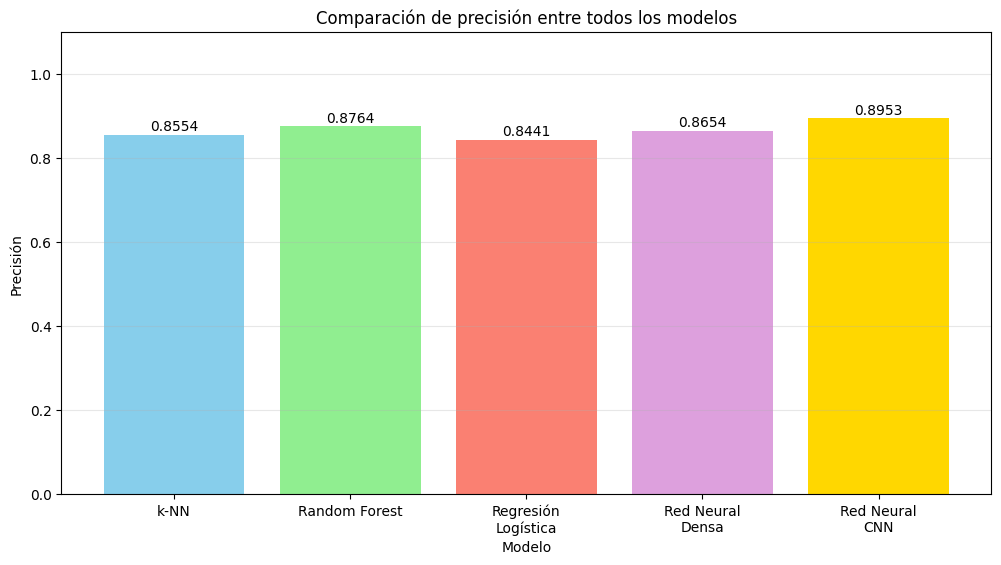


El mejor modelo es: Red Neural CNN con precisión de 0.8953

PARTE 8: ANÁLISIS DE CONFUSIONES Y CLASES PROBLEMÁTICAS

--- Análisis de la matriz de confusión del mejor modelo ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

Pares de clases con mayor confusión:
1. Camisa confundido con Camiseta/Top: 130 casos (13.00%)
2. Camisa confundido con Abrigo: 121 casos (12.10%)
3. Camisa confundido con Suéter: 94 casos (9.40%)
4. Camiseta/Top confundido con Camisa: 85 casos (8.50%)
5. Abrigo confundido con Suéter: 61 casos (6.10%)


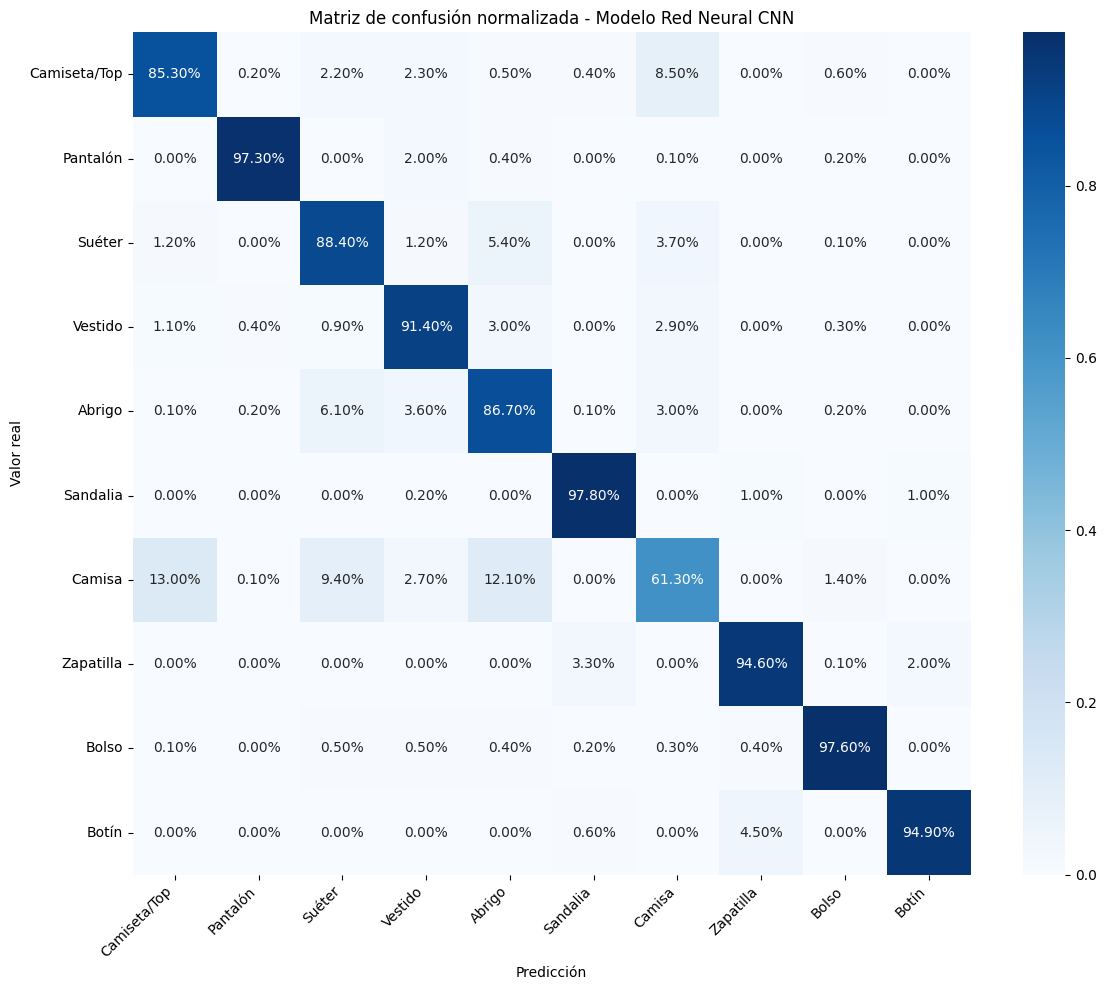


Ejemplos donde Camisa se confunde con Camiseta/Top:


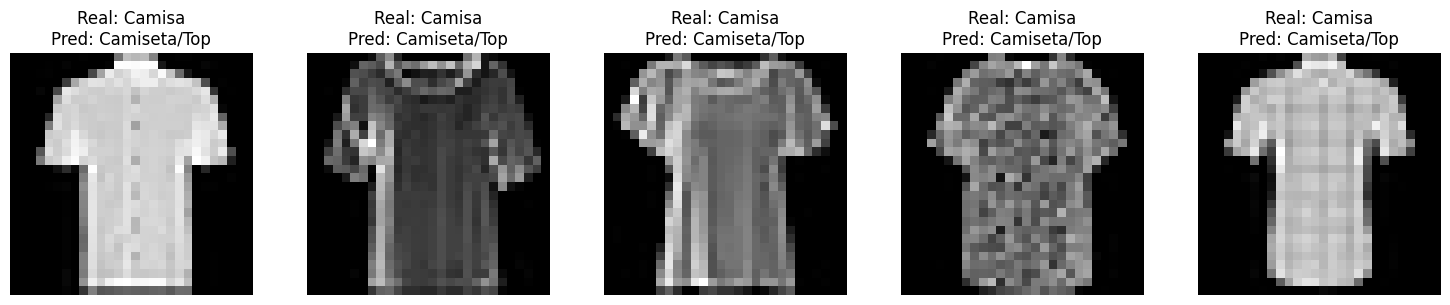

In [12]:
# PARTE 7: COMPARACIÓN FINAL DE TODOS LOS MODELOS
print("\n" + "="*50)
print("PARTE 7: COMPARACIÓN FINAL DE TODOS LOS MODELOS")
print("="*50)

# Evaluate the Dense model and calculate accuracy
_, accuracy_dense = model_dense.evaluate(X_test_flat, y_test_one_hot, verbose=0)

# Evaluate the CNN model and calculate accuracy
_, accuracy_cnn = model_cnn.evaluate(X_test_reshaped, y_test_one_hot, verbose=0)


print("\n--- Comparación final de todos los modelos ---")
print(f"k-NN: {accuracy_knn*100:.2f}%")
print(f"Random Forest: {accuracy_rf*100:.2f}%")
print(f"Regresión Logística: {accuracy_lr*100:.2f}%")
print(f"Red Neural Densa: {accuracy_dense*100:.2f}%")
print(f"Red Neural CNN: {accuracy_cnn*100:.2f}%")

# Gráfico comparativo
plt.figure(figsize=(12, 6))
models = ['k-NN', 'Random Forest', 'Regresión\nLogística', 'Red Neural\nDensa', 'Red Neural\nCNN']
accuracies = [accuracy_knn, accuracy_rf, accuracy_lr, accuracy_dense, accuracy_cnn]
colors = ['skyblue', 'lightgreen', 'salmon', 'plum', 'gold']

plt.bar(models, accuracies, color=colors)
plt.title('Comparación de precisión entre todos los modelos')
plt.xlabel('Modelo')
plt.ylabel('Precisión')
plt.ylim(0, 1.1)

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f'{acc:.4f}', ha='center')

plt.grid(axis='y', alpha=0.3)
plt.show()

# Encontrar el mejor modelo
accuracies_dict = {
    'k-NN': accuracy_knn,
    'Random Forest': accuracy_rf,
    'Regresión Logística': accuracy_lr,
    'Red Neural Densa': accuracy_dense,
    'Red Neural CNN': accuracy_cnn
}

best_model_name = max(accuracies_dict, key=accuracies_dict.get)
best_accuracy = accuracies_dict[best_model_name]

print(f"\nEl mejor modelo es: {best_model_name} con precisión de {best_accuracy:.4f}")

# PARTE 8: ANÁLISIS DE CONFUSIONES Y CLASES PROBLEMÁTICAS
print("\n" + "="*50)
print("PARTE 8: ANÁLISIS DE CONFUSIONES Y CLASES PROBLEMÁTICAS")
print("="*50)

# Analizar la matriz de confusión del mejor modelo
print("\n--- Análisis de la matriz de confusión del mejor modelo ---")

# Obtener la matriz de confusión del mejor modelo
if best_model_name == 'k-NN':
    best_cm = cm_knn
    best_preds = y_pred_knn
elif best_model_name == 'Random Forest':
    best_cm = cm_rf
    best_preds = y_pred_rf
elif best_model_name == 'Regresión Logística':
    best_cm = cm_lr
    best_preds = y_pred_lr
elif best_model_name == 'Red Neural Densa':
    best_preds = np.argmax(model_dense.predict(X_test_flat), axis=1)
    best_cm = confusion_matrix(y_test, best_preds)
else:  # CNN
    best_preds = np.argmax(model_cnn.predict(X_test_reshaped), axis=1) # Get predictions from the CNN model
    best_cm = confusion_matrix(y_test, best_preds)

# Normalizar la matriz de confusión
cm_normalized = best_cm.astype('float') / best_cm.sum(axis=1)[:, np.newaxis]

# Encontrar los pares de clases con mayor confusión
print("\nPares de clases con mayor confusión:")
confusion_pairs = []
for i in range(10):
    for j in range(10):
        if i != j:
            confusion_pairs.append((i, j, best_cm[i, j], cm_normalized[i, j]))

# Ordenar por confusión normalizada
confusion_pairs.sort(key=lambda x: x[3], reverse=True)

# Mostrar los 5 pares con mayor confusión
for i, (true_class, pred_class, count, norm_count) in enumerate(confusion_pairs[:5]):
    print(f"{i+1}. {class_names[true_class]} confundido con {class_names[pred_class]}: {count} casos ({norm_count:.2%})")

# Visualizar la matriz de confusión normalizada
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=True,
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de confusión normalizada - Modelo {best_model_name}')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualizar ejemplos de las confusiones más comunes
top_confusion = confusion_pairs[0]
true_class, pred_class = top_confusion[0], top_confusion[1]

# Encontrar ejemplos de esta confusión
confused_indices = np.where((y_test == true_class) & (best_preds == pred_class))[0]

if len(confused_indices) > 0:
    print(f"\nEjemplos donde {class_names[true_class]} se confunde con {class_names[pred_class]}:")
    num_examples = min(5, len(confused_indices))

    plt.figure(figsize=(15, 3))
    for i in range(num_examples):
        idx = confused_indices[i]
        plt.subplot(1, num_examples, i+1)
        plt.imshow(X_test[idx], cmap='gray')
        plt.title(f'Real: {class_names[true_class]}\nPred: {class_names[pred_class]}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [13]:
# PARTE 9: CONCLUSIONES
print("\n" + "="*50)
print("PARTE 9: CONCLUSIONES")
print("="*50)

print("\n--- Conclusiones del Análisis Fashion MNIST ---")
print(f"1. Se entrenaron cinco modelos diferentes sobre el dataset Fashion MNIST.")
print(f"2. El modelo con mejor desempeño fue: {best_model_name} con precisión de {best_accuracy:.4f} ({best_accuracy*100:.2f}%).")
print(f"3. Fashion MNIST es más desafiante que MNIST original, con precisiones generalmente más bajas.")
print(f"4. Las clases más difíciles de clasificar fueron:")
for i, (true_class, pred_class, count, norm_count) in enumerate(confusion_pairs[:3]):
    print(f"   - {class_names[true_class]} confundido con {class_names[pred_class]}: {norm_count:.2%} de confusión")
print("5. Las redes neuronales convolucionales se desempeñan significativamente mejor debido a su capacidad para capturar patrones espaciales en las imágenes.")
print("6. A diferencia de MNIST con dígitos, Fashion MNIST tiene características visuales más complejas como texturas y formas variadas.")
print("7. Este dataset es más representativo de problemas de visión por computadora del mundo real.")

# Recomendaciones adicionales
print("\n--- Recomendaciones para mejorar los modelos ---")
print("1. Aumentación de datos: Aplicar rotaciones, traslaciones y zoom para incrementar el conjunto de entrenamiento.")
print("2. Arquitecturas CNN más profundas: Probar redes como ResNet o DenseNet para capturar características más complejas.")
print("3. Transfer Learning: Utilizar modelos pre-entrenados en conjuntos de datos más grandes.")
print("4. Hiperparámetros: Realizar una búsqueda exhaustiva de hiperparámetros para optimizar los modelos.")
print("5. Ensemble: Combinar predicciones de varios modelos para mejorar la precisión general.")

print("\n" + "="*50)
print("FIN DEL ANÁLISIS DE FASHION MNIST")
print("="*50)


PARTE 9: CONCLUSIONES

--- Conclusiones del Análisis Fashion MNIST ---
1. Se entrenaron cinco modelos diferentes sobre el dataset Fashion MNIST.
2. El modelo con mejor desempeño fue: Red Neural CNN con precisión de 0.8953 (89.53%).
3. Fashion MNIST es más desafiante que MNIST original, con precisiones generalmente más bajas.
4. Las clases más difíciles de clasificar fueron:
   - Camisa confundido con Camiseta/Top: 13.00% de confusión
   - Camisa confundido con Abrigo: 12.10% de confusión
   - Camisa confundido con Suéter: 9.40% de confusión
5. Las redes neuronales convolucionales se desempeñan significativamente mejor debido a su capacidad para capturar patrones espaciales en las imágenes.
6. A diferencia de MNIST con dígitos, Fashion MNIST tiene características visuales más complejas como texturas y formas variadas.
7. Este dataset es más representativo de problemas de visión por computadora del mundo real.

--- Recomendaciones para mejorar los modelos ---
1. Aumentación de datos: Ap